In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("Reviews.csv")

print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [53]:
df = df[["Score", "Summary", "Text"]]


In [54]:
df = df.dropna()

print(df.shape)

(568427, 3)


In [55]:
df = df[df["Score"] != 3]

df["sentiment"] = df["Score"].apply(lambda x: 1 if x >= 4 else 0)

df.head()

,Score,Summary,Text,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,1
3,2,Cough Medicine,If you are looking for the secret ingredient i...,0
4,5,Great taffy,Great taffy at a great price. There was a wid...,1


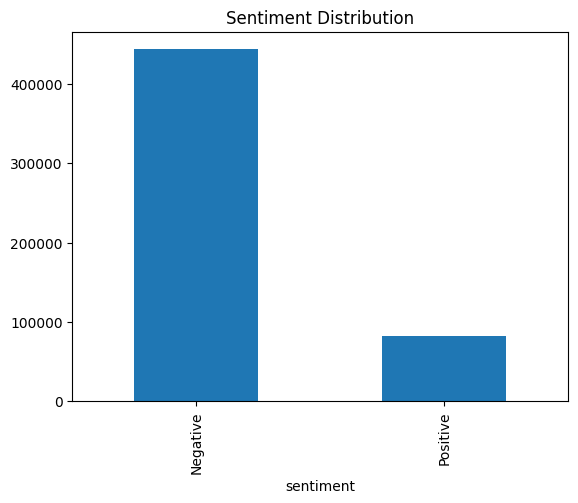

In [56]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xticks([0,1], ["Negative", "Positive"])
plt.show()

In [57]:
print(df["sentiment"].value_counts())


sentiment
1    443777
0     82012
Name: count, dtype: int64


In [58]:
df["review"] = df["Summary"] + " " + df["Text"]

df["review_length"] = df["review"].apply(lambda x: len(x.split()))

df["review_length"].describe()

count    525789.000000
mean         83.080163
std          79.237584
min           4.000000
25%          37.000000
50%          59.000000
75%         100.000000
max        2526.000000
Name: review_length, dtype: float64

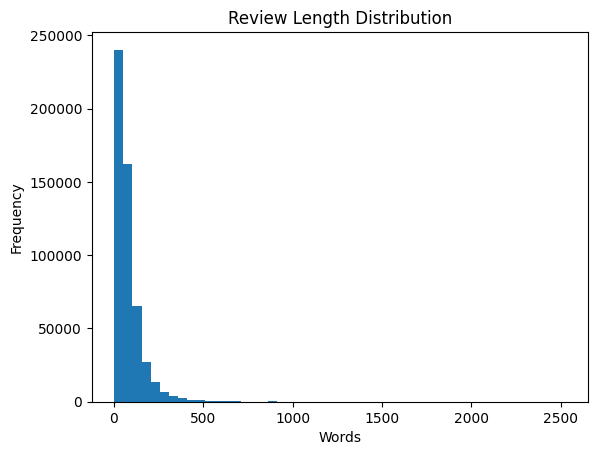

In [59]:
plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [60]:
#%pip install nltk

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [61]:
import re
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

def clean_text_from_stopwords(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
df["clean_review_no_stopwords"] = df["review"].apply(clean_text_from_stopwords)

In [62]:
df[["review","clean_review", "clean_review_no_stopwords"]].head()

,review,clean_review,clean_review_no_stopwords
0,Good Quality Dog Food I have bought several of...,good quality dog food i have bought several of...,good quality dog food bought several vitality ...
1,Not as Advertised Product arrived labeled as J...,not a advertised product arrived labeled a jum...,advertised product arrived labeled jumbo salte...
2,"""Delight"" says it all This is a confection tha...",delight say it all this is a confection that h...,delight says confection around centuries light...
3,Cough Medicine If you are looking for the secr...,cough medicine if you are looking for the secr...,cough medicine looking secret ingredient robit...
4,Great taffy Great taffy at a great price. The...,great taffy great taffy at a great price there...,great taffy great taffy great price wide assor...


In [63]:
df = df.sample(80000, random_state=42)

print(df.shape)

(80000, 8)


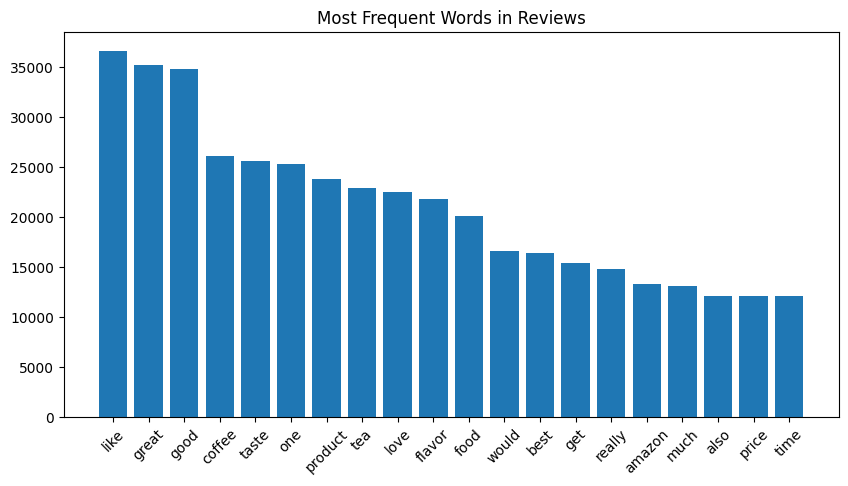

In [64]:
from collections import Counter

all_words = " ".join(df["clean_review_no_stopwords"]).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words in Reviews")
plt.show()

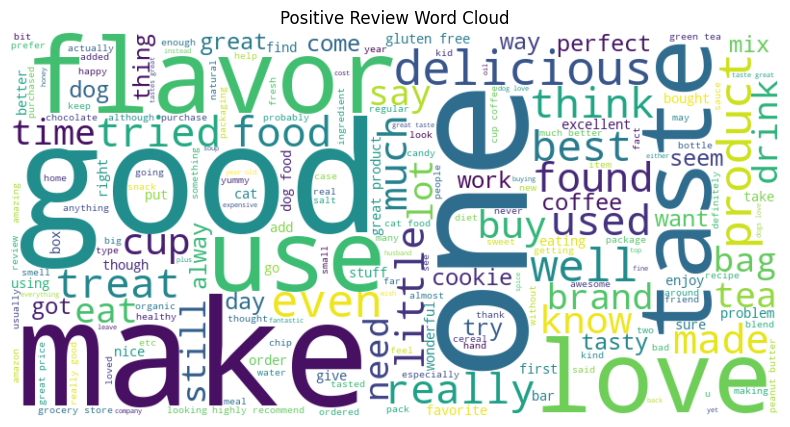

In [65]:
#%pip install wordcloud
from wordcloud import WordCloud

positive_text = " ".join(df[df["sentiment"]==1]["clean_review_no_stopwords"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

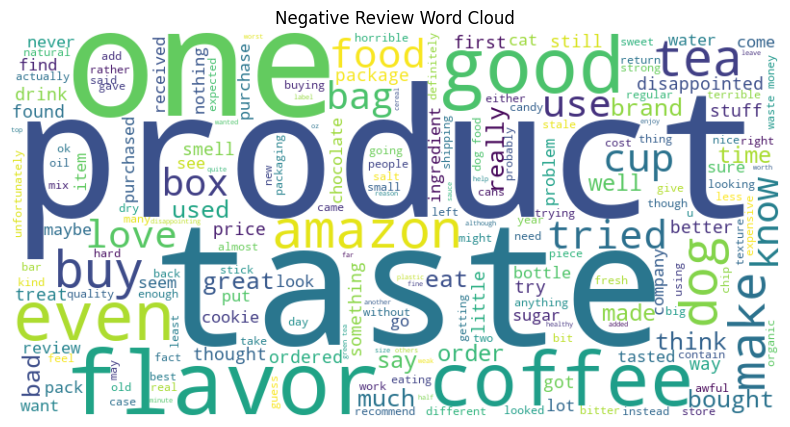

In [66]:
negative_text = " ".join(df[df["sentiment"]==0]["clean_review_no_stopwords"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [67]:
positive_words = " ".join(df[df["sentiment"]==1]["clean_review_no_stopwords"]).split()
negative_words = " ".join(df[df["sentiment"]==0]["clean_review_no_stopwords"]).split()

pos_counts = Counter(positive_words)
neg_counts = Counter(negative_words)

top_pos = pos_counts.most_common(15)
top_neg = neg_counts.most_common(15)

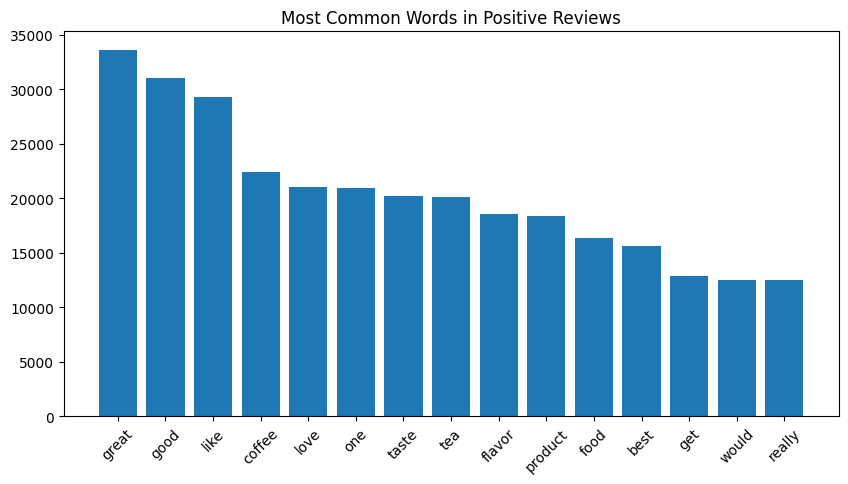

In [68]:
words = [w[0] for w in top_pos]
counts = [w[1] for w in top_pos]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Common Words in Positive Reviews")
plt.xticks(rotation=45)
plt.show()

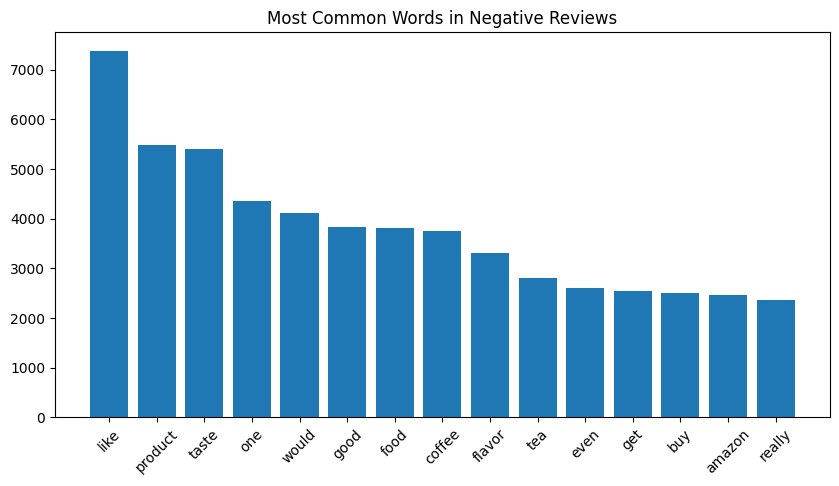

In [69]:
words = [w[0] for w in top_neg]
counts = [w[1] for w in top_neg]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Common Words in Negative Reviews")
plt.xticks(rotation=45)
plt.show()

In [70]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 64000
Test size: 16000


In [71]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LENGTH = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding="post")

print(X_train_pad.shape)

(64000, 200)


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

model = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9210 - loss: 0.2015 - val_accuracy: 0.9433 - val_loss: 0.1407
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.9576 - loss: 0.1134 - val_accuracy: 0.9464 - val_loss: 0.1382
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.9722 - loss: 0.0776 - val_accuracy: 0.9486 - val_loss: 0.1520
Epoch 4/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 57s 64ms/step - accuracy: 0.9815 - loss: 0.0536 - val_accuracy: 0.9480 - val_loss: 0.1540
Epoch 5/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 58s 64ms/step - accuracy: 0.9874 - loss: 0.0371 - val_accuracy: 0.9466 - val_loss: 0.1753


In [74]:
def predict_sentiment(text):
    
    text = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text])
    
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding="post")
    
    prob = model.predict(padded, verbose=0)[0][0]
    
    sentiment = "Positive" if prob > 0.5 else "Negative"
    
    return {
        "review": text,
        "sentiment": sentiment,
        "positive_probability": float(prob)
    }

In [75]:
examples = [
    "Absolutely fantastic flavor, will buy again!",
    "Worst product I have ever bought.",
    "Pretty good but a bit expensive.",
    "Completely awful taste.",
    "I like the flavor, but there are better ones.",
     "It is ok.",
    "It is mediocre, youn can find better"
]

for e in examples:
    print(predict_sentiment(e))

{'review': 'absolutely fantastic flavor will buy again', 'sentiment': 'Positive', 'positive_probability': 0.9999169707298279}
{'review': 'worst product i have ever bought', 'sentiment': 'Negative', 'positive_probability': 0.00042946587200276554}
{'review': 'pretty good but a bit expensive', 'sentiment': 'Positive', 'positive_probability': 0.9442120790481567}
{'review': 'completely awful taste', 'sentiment': 'Negative', 'positive_probability': 0.012312628328800201}
{'review': 'i like the flavor but there are better one', 'sentiment': 'Positive', 'positive_probability': 0.68885338306427}
{'review': 'it is ok', 'sentiment': 'Negative', 'positive_probability': 0.09712354093790054}
{'review': 'it is mediocre youn can find better', 'sentiment': 'Negative', 'positive_probability': 0.08877988159656525}


In [76]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_probs = model.predict(X_test_pad)
pred_labels = (pred_probs > 0.5).astype(int)

print(classification_report(y_test, pred_labels))

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      2467
           1       0.97      0.98      0.97     13533

    accuracy                           0.95     16000
   macro avg       0.92      0.90      0.91     16000
weighted avg       0.95      0.95      0.95     16000



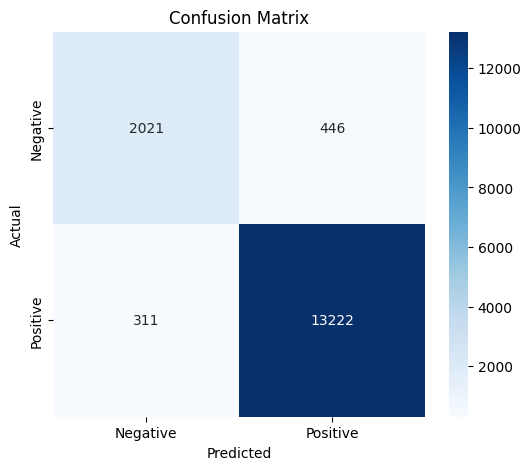

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

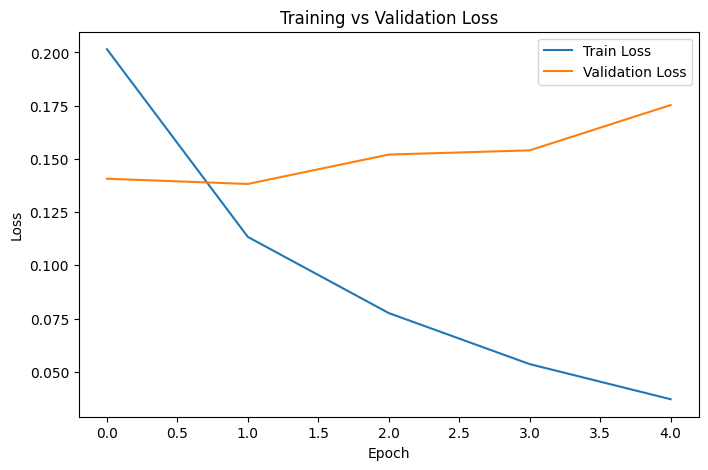

In [78]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

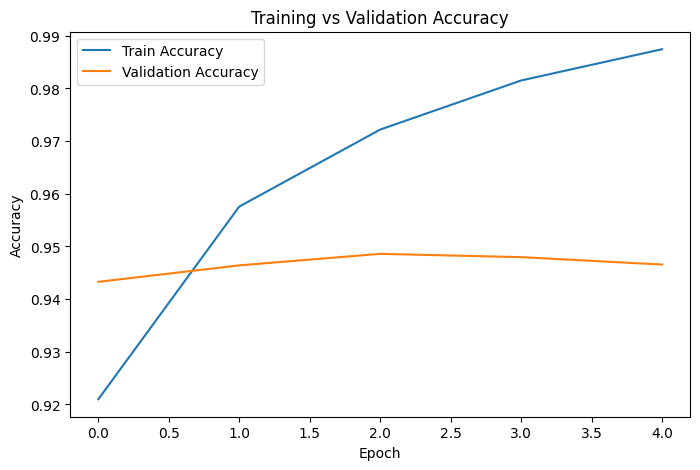

In [79]:
# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
